In [1]:
%pip install kagglehub

In [3]:
import kagglehub
kagglehub.login()

path = kagglehub.competition_download('digit-recognizer')

100%|██████████| 15.3M/15.3M [00:00<00:00, 80.1MB/s]

Extracting files...


In [4]:
import torch
from torch import nn
from torch.utils import data
from torch import optim
import os
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'

test_data = pd.read_csv(f"{path}/test.csv")
train_data = pd.read_csv(f"{path}/train.csv")

#                                                  自動計算圖片數量, 通道數, 長, 寬
train_raw_X = train_data.iloc[:, 1:].values.reshape(-1, 1, 28, 28)/255.0
train_raw_y = train_data.iloc[:, :1].values
train_tensor_X = torch.tensor(train_raw_X, dtype=torch.float32)
train_tensor_y = torch.tensor(train_raw_y)


In [5]:
def VGG_block(num_convs, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.LazyConv2d(out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

def init_cnn(module):
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)

class VGG(nn.Module):

    def __init__(self, arch, lr=0.001, num_classes=10):
        super().__init__()
        layers = [VGG_block(num_convs, out_channels) for num_convs, out_channels in arch]
        self.net = nn.Sequential(
            *layers,
            nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(num_classes)
        )
        self.net.to(device)
        self.lr = lr
        self.trainer = optim.Adam(self.net.parameters(), lr=self.lr)
        self.loss = nn.CrossEntropyLoss()
        self._is_initialized = False

    def _lazy_initialize(self, X):
        _ = self.net(X)
        self.net.apply(init_cnn)
        self.trainer = optim.Adam(self.net.parameters(), lr=self.lr)
        self._is_initialized = True

    def fit(self, X, y):
        X, y = X.to(device), y.squeeze().to(device)
        if not self._is_initialized:
            self._lazy_initialize(X)
        y_hat = self.net(X)
        l = self.loss(y_hat, y)
        self.trainer.zero_grad()
        l.backward()
        self.trainer.step()
        return l.item()
    

    


In [14]:
from sklearn.model_selection import KFold

K = 2
skf = KFold(n_splits=K, shuffle=True)

lr, batch_size, num_epochs = 0.01, 128, 15

conv_arch = ((1, 64), (1, 128), (2, 256))

all_fold_train_loss = []
all_fold_val_loss = []

models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_raw_X, train_raw_y)):
    train_dataset = data.TensorDataset(train_tensor_X[train_idx], train_tensor_y[train_idx])
    val_dataset = data.TensorDataset(train_tensor_X[val_idx], train_tensor_y[val_idx])
    
    train_iter = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_iter = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = VGG(conv_arch)
    current_train_loss = []
    current_val_loss = []
    for epoch in range(num_epochs):

        epoch_train_loss = 0
        for X, y in train_iter:
            epoch_train_loss += model.fit(X, y)
        current_train_loss.append(epoch_train_loss / len(train_iter))

        
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad(): # OutOfMemoryError!!!                          
            for X, y in val_iter:
                X = X.to(device)
                y = y.squeeze().to(device)
                epoch_val_loss += model.loss(model.net(X), y)
        current_val_loss.append(epoch_val_loss / len(train_iter))
        print(f"epochs: {epoch}, loss: ", epoch_train_loss)
    models.append(model)
    
    all_fold_train_loss.append(current_train_loss)
    all_fold_val_loss.append(current_val_loss)

epochs: 0, loss:  122.50598255731165
epochs: 1, loss:  17.025463920086622
epochs: 2, loss:  11.074347320012748
epochs: 3, loss:  8.837920107878745
epochs: 4, loss:  6.484745523892343
epochs: 5, loss:  5.346325912692919
epochs: 6, loss:  3.953606335329823
epochs: 7, loss:  4.086881104216445
epochs: 8, loss:  3.3094408595352434
epochs: 9, loss:  3.2154513669527205
epochs: 10, loss:  4.000619423348326
epochs: 11, loss:  3.621482004110476
epochs: 12, loss:  2.277416918435847
epochs: 13, loss:  2.598051172310079
epochs: 14, loss:  3.1889280593313742
epochs: 0, loss:  118.76543445046991
epochs: 1, loss:  14.925935879349709
epochs: 2, loss:  10.829230104573071
epochs: 3, loss:  6.576101019396447
epochs: 4, loss:  5.1448224352207035
epochs: 5, loss:  4.245472663853434
epochs: 6, loss:  3.530269740280346
epochs: 7, loss:  2.6342689893499482
epochs: 8, loss:  2.5817451027637617
epochs: 9, loss:  4.523452187539078
epochs: 10, loss:  5.290491588573786
epochs: 11, loss:  2.318692339831614
epochs: 1

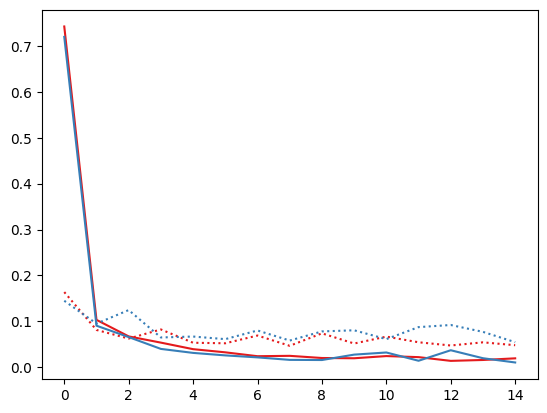

In [15]:
import matplotlib.pyplot as plt

colors = plt.get_cmap('Set1')
for idx in range(K):
    train_loss_data = [x.cpu().item() if isinstance(x, torch.Tensor) else x for x in all_fold_train_loss[idx]]
    val_loss_data = [x.cpu().item() if isinstance(x, torch.Tensor) else x for x in all_fold_val_loss[idx]]
    plt.plot(range(num_epochs), train_loss_data, linestyle='-', color=colors(idx))
    plt.plot(range(num_epochs), val_loss_data, linestyle=':', color=colors(idx))
    

In [16]:
import numpy as np

test_X = test_data.iloc[:, :].values.reshape(-1, 1, 28, 28)/255.0
test_tensor = torch.tensor(test_X, dtype=torch.float32)
test_iter = data.DataLoader(data.TensorDataset(test_tensor), batch_size=batch_size, shuffle=False)

for model in models:
    model.eval()

all_predictions = []

with torch.no_grad():
    for (X_test,) in test_iter:
        X_test = X_test.to(device)
        batch_logits = []

        for model in models:
            outputs = model.net(X_test)
            probs = torch.softmax(outputs, dim=1)
            batch_logits.append(probs.cpu().numpy())

        avg_probs = np.mean(batch_logits, axis=0)
        final_preds = np.argmax(avg_probs, axis=1)
        all_predictions.extend(final_preds)

all_predictions = np.array(all_predictions)

all_predictions

array([2, 0, 9, ..., 3, 9, 2])

In [17]:
submission = pd.DataFrame({
    'ImageId': range(1, len(all_predictions) + 1),
    'Label': all_predictions
})

submission.to_csv('vgg_kfold_submission.csv', index=False)

In [21]:
from google.colab import drive
import shutil
import os

# 1. 掛載 Google Drive 到 Colab 虛擬機
# 執行後會跳出視窗請求權限，請點選「連線到 Google 雲端硬碟」並允許
drive.mount('/content/drive')

# 2. 定義來源檔案路徑與 Google Drive 的目標儲存路徑
source_path = 'vgg_kfold_submission.csv'
# 預設儲存於雲端硬碟的根目錄，您也可以自訂資料夾路徑如 '/content/drive/MyDrive/Colab Notebooks/'
target_path = '/content/drive/MyDrive/'

# 3. 檢查檔案是否存在並執行複製上傳
if os.path.exists(source_path):
    shutil.copy(source_path, target_path)
    print(f"🎉 上傳成功！檔案已儲存至 Google Drive 根目錄，檔名為: vgg_kfold_submission.csv")
else:
    print(f"❌ 找不到來源檔案 {source_path}，請確認先前的預測程式碼是否有成功產生 CSV 檔。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🎉 上傳成功！檔案已儲存至 Google Drive 根目錄，檔名為: vgg_kfold_submission.csv
